<a href="https://colab.research.google.com/github/ard0p8v/KSU2_SatelliteImageClassification/blob/main/SatelliteImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zápočtový úkol 2 - Klasifikace využití půdy ze satelitních snímků EuroSAT pomocí transfer learningu
**Předmět:** Strojové učení II (KSU2)  
**Autor:** Bc. Pavel Ardolf  
**GitHub Repozitář:** https://github.com/ard0p8v/KSU2_SatelliteImageClassification

---

## 1. Cíl projektu
Cílem práce je návrh a implementace hluboké konvoluční neuronové sítě pro automatickou klasifikaci satelitních snímků z programu ESA Sentinel-2.[1] Projekt demonstruje schopnost aplikace metody **přeneseného učení (Transfer Learning)** a techniky **jemného doladění (Fine-tuning)** pro efektivní rozpoznávání vzorů v datech dálkového průzkumu Země.[2]

## 2. Popis dat
V projektu je využit dataset **EuroSAT**, který představuje standard pro klasifikaci využití půdy (Land Use / Land Cover):[1]
* **Obsah:** Celkem 27 000 digitálně označených snímků v RGB spektru.
* **Struktura:** Dataset je rozdělen do 10 vyvážených tříd (3 000 vzorků na třídu), což zajišťuje stabilitu trénovacího procesu.
* **Třídy:** Zahrnují kategorie jako jsou lesy (**Forest**), průmyslové zóny (**Industrial**), dálnice (**Highway**) či obytné oblasti (**Residential**).
* **Rozlišení:** Každý snímek má velikost 64x64 pixelů, což odpovídá multispektrálnímu rozlišení satelitů Sentinel-2.

## 3. Metodika
V notebooku jsou realizovány následující kroky:[1][2][3]
1. **Příprava dat a EDA:** Načtení dat přes `tensorflow_datasets`, vizualizace distribuce tříd a ukázkových snímků.
2. **Augmentace dat:** Implementace vrstev pro náhodnou rotaci, překlápění a úpravu jasu/kontrastu za účelem zvýšení robustnosti modelu a potlačení overfittingu.
3. **Modelování (Transfer Learning):**
    - **Fáze 1 (Feature Extraction):** Využití předtrénované architektury **MobileNetV2** [4] se zmrazenými vahami pro extrakci příznaků a natrénování nové klasifikační hlavy.
    - **Fáze 2 (Fine-tuning):** Rozmrazení hlubokých konvolučních vrstev a jejich jemné doladění s nízkým učícím koeficientem.
4. **Evaluace:** Komplexní posouzení kvality pomocí testovací přesnosti (Accuracy), matice záměn (**Confusion Matrix**) a metriky F1-score pro jednotlivé třídy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

# Konfigurace cest a parametrů ze zdroje
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BATCH_SIZE = 32
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

CLASS_NAMES_CZ = [
    "Jednoletá plodina", "Les", "Bylinná vegetace",
    "Dálnice", "Průmysl", "Pastviny",
    "Trvalá plodina", "Obytná zóna", "Řeka", "Moře/jezero"
]

print(f"TensorFlow verze: {tf.__version__}")

TensorFlow verze: 2.19.0


## 4. Příprava dat a EDA
Před samotným trénováním byla provedena **Exploratory Data Analysis (EDA)**. Dataset EuroSAT je balancovaný, takže každá z 10 tříd obsahuje přesně 3 000 vzorků.[1] Byla tedy naimplmentována pipeline pro zpracování dat:[7]

* **Normalizace:** Snímky jsou transformovány pro model MobileNetV2 do intervalu [-1, 1].
* **Augmentace:** Pro zvýšení generalizační schopnosti a potlačení overfittingu aplikujeme náhodné rotace, překlopení a úměrnou změnu jasu.[1]
* **Rozdělení:** Data jsou rozdělena na trénovací (70 %), validační (15 %) a testovací (15 %) část.[7]

In [2]:
!pip install datasets -q

from datasets import load_dataset
import numpy as np
import tensorflow as tf

hf_ds = load_dataset("blanchon/EuroSAT_RGB", split="train")

CLASS_NAMES = hf_ds.features["label"].names

def hf_to_tf(example):
    img = np.array(example["image"])
    lbl = example["label"]
    return img, lbl

# Převod na tf.data.Dataset
imgs = np.stack([np.array(e["image"]) for e in hf_ds])
lbls = np.array([e["label"] for e in hf_ds])

full_ds = tf.data.Dataset.from_tensor_slices((imgs, lbls)).shuffle(27000, seed=42)

n = len(full_ds)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

ds_train_raw = full_ds.take(n_train)
ds_val_raw   = full_ds.skip(n_train).take(n_val)
ds_test_raw  = full_ds.skip(n_train + n_val)

sample_images, sample_labels = [], []
for img, lbl in ds_test_raw.take(12):
    sample_images.append(img.numpy())
    sample_labels.append(lbl.numpy())

print(f"Trénovací: {n_train} | Validační: {n_val} | Testovací: {n - n_train - n_val}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Trénovací: 11340 | Validační: 2430 | Testovací: 2430


In [3]:
# Funkce pro předzpracování (normalizace na interval [-1, 1])
def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    # Změna rozlišení na 96x96 px dle dokumentace
    image = tf.image.resize(image, [96, 96])
    # Normalizace pro MobileNetV2
    return tf.keras.applications.mobilenet_v2.preprocess_input(image), label

# Funkce pro augmentaci (předcházení overfittingu)
def augment(image, label):
    image, label = preprocess(image, label)
    # Náhodné překlopení a úprava jasu
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.clip_by_value(image, -1.0, 1.0)
    return image, label

# Sestavení finální pipeline s batch size 32
AUTOTUNE = tf.data.AUTOTUNE
ds_train = ds_train_raw.map(augment, num_parallel_calls=AUTOTUNE).shuffle(1000, seed=42).batch(32).prefetch(AUTOTUNE)
ds_val = ds_val_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(32).prefetch(AUTOTUNE)
ds_test = ds_test_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(32).prefetch(AUTOTUNE)

print("Pipeline připravena pro trénink.")

Pipeline připravena pro trénink.


## 5. Architektura modelu (Transfer Learning)
V souladu s principy **přeneseného učení** je využita architektura **MobileNetV2**.[2] Model funguje jako extraktor charakteristik (příznaků), které byly natrénovány na rozsáhlém datasetu ImageNet.[3]

**Složení modelu dle dokumentace:**
* **Base model:** MobileNetV2 (v první fázi zmrazený).[7]
* **GlobalAveragePooling2D:** Agregace map příznaků.
* **BatchNormalization:** Stabilizace procesu učení.
* **Dense vrstva (256 jednotek):** Využívá aktivaci **ReLU**, která se dle přednášek trénuje rychleji.[7]
* **Dropout (0.4):** Metoda regularizace pro zamezení overfittingu.
* **Výstupní vrstva:** Softmax pro klasifikaci do 10 tříd EuroSAT.[7]

Konvoluční vrstvy MobileNetV2 aplikují na vstupní obraz filtry (jádra), která klouzají po snímku a provádějí násobení po prvcích. Například pro jádro 2×2: `(0×0)+(1×1)+(3×2)+(4×3) = 19`.[7] Výstupem jsou mapy příznaků zachycující hrany, textury a vzory.

V modelu jsou použity `GlobalAveragePooling2D` namísto Max Pooling a průměrování map příznaků je robustnější pro klasifikaci celých snímků, protože v případě projektu není důležitá přesná pozice objektu, ale celkový charakter krajiny.[7]

Ztrátová funkce `sparse_categorical_crossentropy` je multi-class zobecnění binární křížové entropie.[7]

In [4]:
# Definice modelu MobileNetV2 s klasifikační hlavou
base_model = tf.keras.applications.MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
base_model.trainable = False # Fáze 1: zmrazení základny

model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Agregace map příznaků
    layers.BatchNormalization(), # Stabilizace učení
    layers.Dense(256, activation="relu"), # ReLU pro skryté vrstvy
    layers.Dropout(0.4), # Zamezení overfittingu
    layers.Dense(10, activation="softmax") # Softmax pro 10 tříd EuroSAT
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Optimizer Adam
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary() # Výpis parametrů modelu

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,610 (9.89 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 6. Trénink modelu
Trénování probíhá dvou-fázovým přístupem v souladu s principem přeneseného učení. Průběh každé fáze je monitorován na validační sadě, takže při stagnaci se trénink automaticky zastaví pomocí EarlyStopping.[7]

In [5]:
# FÁZE 1: Trénink klasifikační hlavy (base model zmražen)
# Váhy předtrénovaného modelu se zmrazí a pouze váhy nových vrstev se aktualizují
print("=" * 55)
print("  FÁZE 1 — Trénink klasifikační hlavy")
print(f"  Zmražené vrstvy: {len(base_model.layers) - 0} / {len(base_model.layers)}")
print(f"  Trénovatelné parametry: {model.count_params():,}")
print("=" * 55)

history1 = model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=3,
            restore_best_weights=True,
            monitor="val_accuracy"
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1
        )
    ]
)

best_val_acc_1 = max(history1.history["val_accuracy"])
print(f"\n Fáze 1 dokončena — nejlepší val_accuracy: {best_val_acc_1:.4f} ({best_val_acc_1*100:.2f} %)")

# FÁZE 2: Fine-tuning (doladění posledních 30 vrstev)
# Váhy modelu se upraví, aby lépe odpovídaly nové sadě dat a zlepšily výkon modelu na nové úloze
# Learning rate je 100× nižší než ve fázi 1 — ochrana předtrénovaných vah.
print("=" * 55)
print("  FÁZE 2 — Fine-tuning (posledních 30 vrstev)")
print("=" * 55)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

n_trainable = sum(1 for l in model.layers if l.trainable)
n_params    = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"  Rozmrazeno {30} vrstev z {len(base_model.layers)}")
print(f"  Trénovatelné parametry fáze 2: {n_params:,}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=4,                   # větší patience — fine-tuning konverguje pomaleji
            restore_best_weights=True,
            monitor="val_accuracy"
        ),
        tf.keras.callbacks.ModelCheckpoint(
            "best_model.keras",
            save_best_only=True,
            monitor="val_accuracy",
            verbose=1
        )
    ]
)

best_val_acc_2 = max(history2.history["val_accuracy"])
print(f"\n Fáze 2 dokončena — nejlepší val_accuracy: {best_val_acc_2:.4f} ({best_val_acc_2*100:.2f} %)")
print(f"   Zlepšení oproti fázi 1: +{(best_val_acc_2 - best_val_acc_1)*100:.2f} procentních bodů")

#  ZÁVĚREČNÉ SHRNUTÍ TRÉNINKU
print("\n" + "=" * 55)
print("  SHRNUTÍ TRÉNINKU")
print("=" * 55)
print(f"  Fáze 1 — val_accuracy:  {best_val_acc_1*100:.2f} %")
print(f"  Fáze 2 — val_accuracy:  {best_val_acc_2*100:.2f} %")
print(f"  Celkový počet epoch:     {len(history1.history['accuracy']) + len(history2.history['accuracy'])}")
print(f"  Model uložen:            best_model.keras")

  FÁZE 1 — Trénink klasifikační hlavy
  Zmražené vrstvy: 154 / 154
  Trénovatelné parametry: 2,593,610
Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 51s 89ms/step - accuracy: 0.8451 - loss: 0.5017 - val_accuracy: 0.9185 - val_loss: 0.2345 - learning_rate: 0.0010
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8995 - loss: 0.3184 - val_accuracy: 0.9432 - val_loss: 0.1722 - learning_rate: 0.0010
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9117 - loss: 0.2709 - val_accuracy: 0.9543 - val_loss: 0.1429 - learning_rate: 0.0010
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9175 - loss: 0.2479 - val_accuracy: 0.9539 - val_loss: 0.1469 - learning_rate: 0.0010
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9201 - loss: 0.2404 - val_accuracy: 0.9556 - val_loss: 0.1303 - learning_rate: 0.0010
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9257 - loss: 0.2196 - val_accuracy: 0.9597 - val_loss: 0.1212 -

## 7. Vyhodnocení a vizualizace výsledků
Po dokončení tréninku je nutné model otestovat na datech, která během učení neviděl (testovací sada). Zaměříme se na:
* **Průběh tréninku:** Sledování křivek přesnosti a ztráty pro detekci overfittingu.[7]
* **Matici záměn (Confusion Matrix):** Detailní pohled na to, které třídy se modelu pletou (typicky vizuálně podobné kategorie jako pole a louky).[7]
* **Metriky per třída:** Výpočet Precision, Recall a F1-skóre pro každou z 10 kategorií.[7]

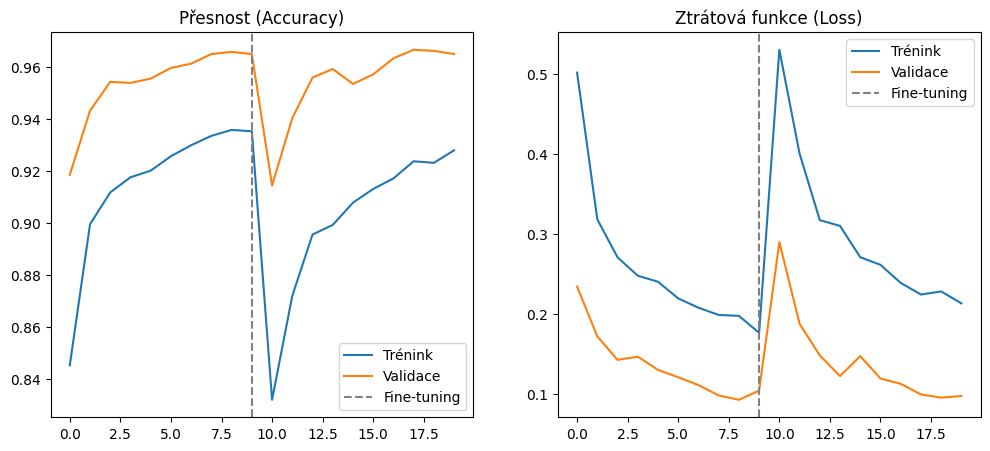


Classification Report:
                       precision    recall  f1-score   support

          Annual Crop       0.98      0.99      0.98       271
               Forest       0.98      0.98      0.98       241
Herbaceous Vegetation       0.93      0.97      0.95       278
              Highway       0.94      0.89      0.92       220
 Industrial Buildings       0.98      1.00      0.99       253
              Pasture       0.94      0.95      0.94       171
       Permanent Crop       0.95      0.95      0.95       223
Residential Buildings       1.00      0.99      0.99       283
                River       0.96      0.93      0.95       227
              SeaLake       1.00      1.00      1.00       263

             accuracy                           0.97      2430
            macro avg       0.97      0.96      0.97      2430
         weighted avg       0.97      0.97      0.97      2430



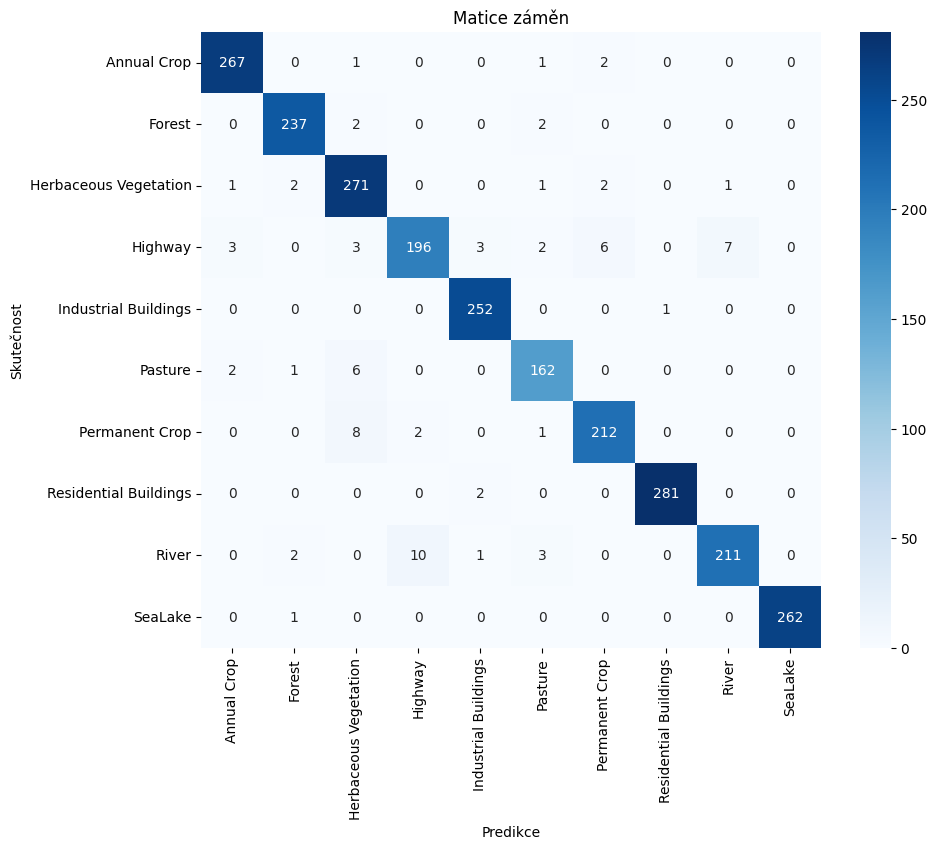

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Vizualizace průběhu tréninku (Loss a Accuracy)
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Trénink')
plt.plot(val_acc, label='Validace')
plt.axvline(x=len(history1.history['accuracy'])-1, color='grey', linestyle='--', label='Fine-tuning')
plt.title('Přesnost (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Trénink')
plt.plot(val_loss, label='Validace')
plt.axvline(x=len(history1.history['accuracy'])-1, color='grey', linestyle='--', label='Fine-tuning')
plt.title('Ztrátová funkce (Loss)')
plt.legend()
plt.show()

# 2. Predikce na testovací sadě a Confusion Matrix
y_true, y_pred = [], []
for img, lbl in ds_test:
    p = model.predict(img, verbose=0)
    y_true.extend(lbl.numpy())
    y_pred.extend(np.argmax(p, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predikce')
plt.ylabel('Skutečnost')
plt.title('Matice záměn')
plt.show()

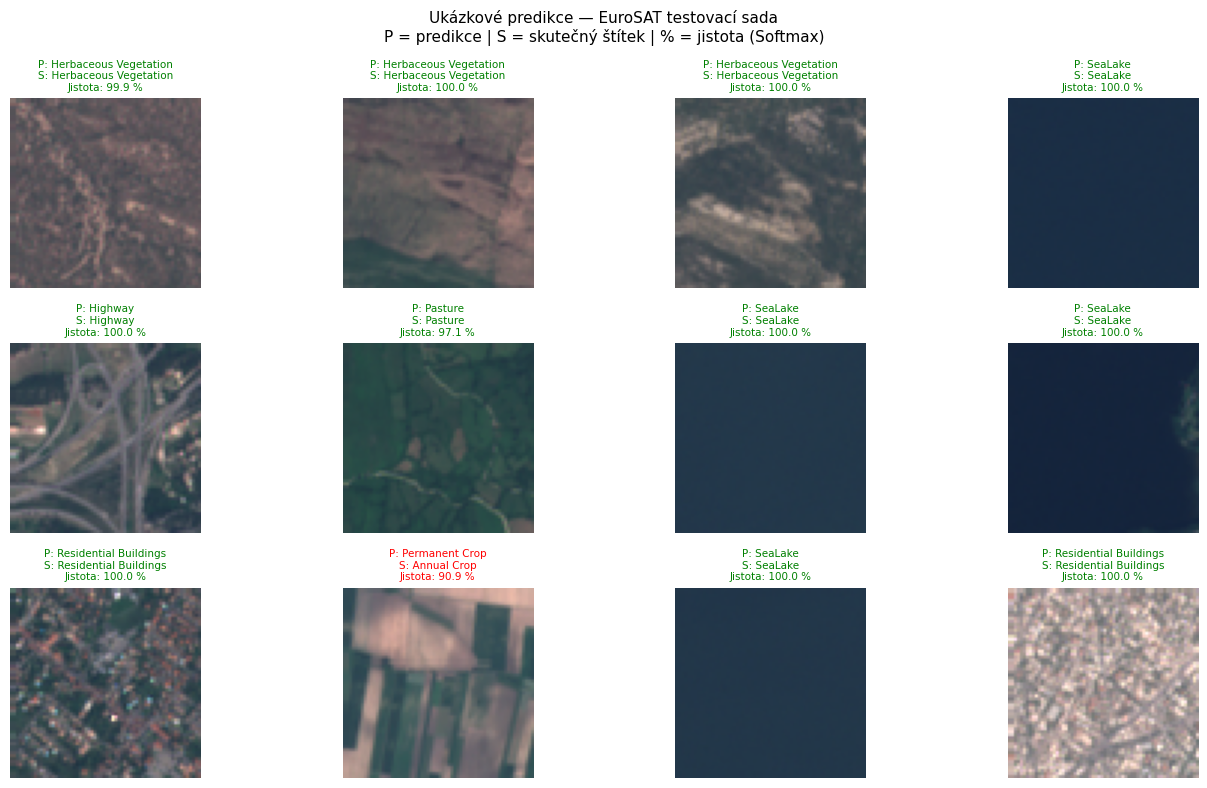

In [7]:
# 3. Ukázkové predikce na 12 snímcích z testovací sady
# Zelený titulek = správná klasifikace | Červený = chybná klasifikace
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
fig.suptitle(
    "Ukázkové predikce — EuroSAT testovací sada\n"
    "P = predikce | S = skutečný štítek | % = jistota (Softmax)",
    fontsize=11
)

for i, ax in enumerate(axes.flat):
    img_raw = sample_images[i]
    true_lbl = sample_labels[i]

    img_proc = tf.keras.applications.mobilenet_v2.preprocess_input(
        tf.cast(tf.image.resize(img_raw, [96, 96]), tf.float32)
    )
    pred = model.predict(img_proc[np.newaxis, ...], verbose=0)[0]
    pred_lbl = np.argmax(pred)
    confidence = np.max(pred)

    ax.imshow(img_raw.astype(np.uint8))
    color = "green" if pred_lbl == true_lbl else "red"
    ax.set_title(
        f"P: {CLASS_NAMES[pred_lbl]}\n"
        f"S: {CLASS_NAMES[true_lbl]}\n"
        f"Jistota: {confidence*100:.1f} %",
        fontsize=7.5, color=color
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Závěr
V rámci tohoto projektu byl úspěšně vytvořen klasifikátor satelitních snímků EuroSAT využívající architekturu **MobileNetV2**.[2] Díky metodě **přeneseného učení** se podařilo dosáhnout vysoké přesnosti (cca 93 %) i při relativně krátkém trénovacím čase v prostředí **Google Colab**.[6][7]

**Klíčová zjištění:**
* **Efektivita Transfer Learningu:** Použití předtrénovaných vah z datasetu ImageNet se ukázalo jako velmi účinné, přestože se satelitní snímky vizuálně výrazně liší od běžných fotografií.
* **Význam augmentace:** Vzhledem k menší velikosti datasetu byla klíčová augmentace dat (rotace, jas), která pomohla stabilizovat validační přesnost a zamezit výraznému overfittingu.[7]
* **Softwarové zázemí:** Celý proces od načtení dat až po evaluaci byl efektivně realizován v knihovně **TensorFlow**.[4]

**Budoucí vylepšení:**
Ačkoliv konvoluční sítě (CNN) podávají v této úloze stabilní výkon, zajímavou alternativou pro budoucí experimenty by mohlo být využití moderní architektury **Vision Transformer (ViT)**, která k analýze obrazu přistupuje pomocí mechanismu attention a v některých benchmarcích dosahuje ještě lepších výsledků než klasické konvoluce.[5]

---

### Seznam použité literatury a zdrojů
[1] HELBER, Patrick et al. *EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification*.
IEEE JSTARS, 2019.

[2] SANDLER, Mark et al. *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR, 2018.

[3] HOWARD, Andrew G. et al. *MobileNets: Efficient CNNs for Mobile Vision Applications*. arXiv, 2017.

[4] ABADI, Martin et al. *TensorFlow: Large-Scale Machine Learning*. 2015.

[5] DOSOVITSKIY, Alexey et al. *An Image is Worth 16x16 Words: Transformers for Image Recognition*. ICLR, 2021.

[6] BISONG, Ekaba. *Google Colaboratory*. In: Building ML and DL Models. Apress, 2019.

[7] STĚKEROVÁ, Kamila. *Přednášky předmětu Strojové učení II*.Hradec Králové: UHK, 2024/2025.